In [27]:
import torch.nn as nn
import pandas as pd
import torch
import torchvision
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader, Subset
from tqdm import tqdm
from PIL import Image
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor

Disclaimer: No hubo uso de AI en este notebook.

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

# Cargar y particionar el CIFAR10

In [29]:
# Transform ToTensor() para Tensorear el PIL.Image
train_data = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transforms.ToTensor())
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())

In [30]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

data_base_path = "data/" if IN_COLAB else "../data/asl_data/"


In [31]:
IMG_HEIGHT = 32
IMG_WIDTH = 32
IMG_CHANNELS = 3

# MODELO 1 (Arquitectura original)
class CNNModel_A(nn.Module):
    def __init__(self):
        super().__init__()

        # Convolutional
        self.conv_layers = nn.Sequential(
            nn.Conv2d(IMG_CHANNELS, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 8x8 -> 4x4
        )

        conv_output_size = 128 * 4 * 4

        # Fully-connected
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv_output_size, 512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


## Modelos alternativos

In [32]:
# MODELO B (Utilizando normalización + otro bloque)
class CNNModel_B(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(IMG_CHANNELS, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32x32 -> 16x16
            nn.Dropout2d(0.1),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 16x16 -> 8x8
            nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 8x8 -> 4x4
            nn.Dropout2d(0.1),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 4x4 -> 2x2
            nn.Dropout2d(0.1),
        )

        conv_output_size = 128 * 2 * 2

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv_output_size, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),

            nn.Linear(512, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),

            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# MODELO C (Únicamente cambiando drop-out rates de modelo A)
class CNNModel_C(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(IMG_CHANNELS, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 8x8 -> 4x4
        )

        conv_output_size = 128 * 4 * 4

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv_output_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


# Entrenamiento del modelo

## Función de entrenamiento

In [33]:
def get_batch_accuracy(outputs, y_batch, dataset_size):
    _, pred = torch.max(outputs, dim=1)
    correct = (pred == y_batch).sum().item()
    return correct

def train(model, train_loader, test_loader, loss_fn, optimizer, epochs):

    train_losses = torch.zeros(epochs)
    train_accuracies = torch.zeros(epochs)
    test_losses = torch.zeros(epochs)
    test_accuracies = torch.zeros(epochs)

    train_dataset_size = len(train_loader.dataset)
    test_dataset_size = len(test_loader.dataset)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

            train_correct += get_batch_accuracy(outputs, y_batch, train_dataset_size)

        avg_train_loss = train_loss / train_dataset_size
        train_accuracy = 100.0 * train_correct / train_dataset_size

        train_losses[epoch] = avg_train_loss
        train_accuracies[epoch] = train_accuracy

        model.eval()
        test_loss = 0.0
        test_correct = 0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                outputs = model(X_batch)
                loss = loss_fn(outputs, y_batch)

                test_loss += loss.item() * X_batch.size(0)

                _, pred = torch.max(outputs, dim=1)
                test_correct += get_batch_accuracy(outputs, y_batch, train_dataset_size)

        avg_test_loss = test_loss / test_dataset_size
        test_accuracy = 100.0 * test_correct / test_dataset_size

        test_losses[epoch] = avg_test_loss
        test_accuracies[epoch] = test_accuracy

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.2f}%")
        print(f"  Test Loss:  {avg_test_loss:.4f} | Test Acc:  {test_accuracy:.2f}%")
        print("-" * 50)

    return train_losses, train_accuracies, test_losses, test_accuracies

In [34]:
def plot_learning_curves(train_losses, test_losses, train_accuracies, test_accuracies, epochs):
    epochs_range = range(1, epochs + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Losses
    ax1.plot(epochs_range, train_losses, label="Train Loss")
    ax1.plot(epochs_range, test_losses, label="Test Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Learning Curves - Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracies
    ax2.plot(epochs_range, train_accuracies, label="Train Accuracy")
    ax2.plot(epochs_range, test_accuracies, label="Test Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_title("Learning Curves - Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Entrenar modelo A

In [35]:
# Parameter macros (No se cambian)
learning_rate = 0.001
epochs = 10
batch_size = 32

# Para resolver el problema multi-clase
loss_fn = nn.CrossEntropyLoss()

model_1 = CNNModel_A()
model_1 = model_1.to(device)

# Uso una extensión menor de datos porque no quiero usar GPU T4 por ahora y tampoco quiero tardar mucho lol
small_train = Subset(train_data, range(26000))
small_test = Subset(test_data, range(5000))

optimizer_1 = Adam(model_1.parameters(), lr=learning_rate)

train_loader = DataLoader(small_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(small_test, batch_size=batch_size, shuffle=True)

train_losses_1, train_accuracies_1, test_losses_1, test_accuracies_1 = train(model_1, train_loader, test_loader, loss_fn, optimizer_1, epochs)

Epoch [1/10]
  Train Loss: 1.6836 | Train Acc: 37.53%
  Test Loss:  1.3622 | Test Acc:  51.14%
--------------------------------------------------
Epoch [2/10]
  Train Loss: 1.2683 | Train Acc: 54.11%
  Test Loss:  1.1675 | Test Acc:  58.24%
--------------------------------------------------
Epoch [3/10]
  Train Loss: 1.0579 | Train Acc: 62.32%
  Test Loss:  1.0068 | Test Acc:  64.72%
--------------------------------------------------
Epoch [4/10]
  Train Loss: 0.9093 | Train Acc: 67.55%
  Test Loss:  0.9847 | Test Acc:  66.90%
--------------------------------------------------
Epoch [5/10]
  Train Loss: 0.8002 | Train Acc: 71.85%
  Test Loss:  0.9347 | Test Acc:  67.84%
--------------------------------------------------
Epoch [6/10]
  Train Loss: 0.6942 | Train Acc: 75.29%
  Test Loss:  0.8977 | Test Acc:  69.78%
--------------------------------------------------
Epoch [7/10]
  Train Loss: 0.5952 | Train Acc: 78.66%
  Test Loss:  0.9577 | Test Acc:  69.16%
-----------------------------

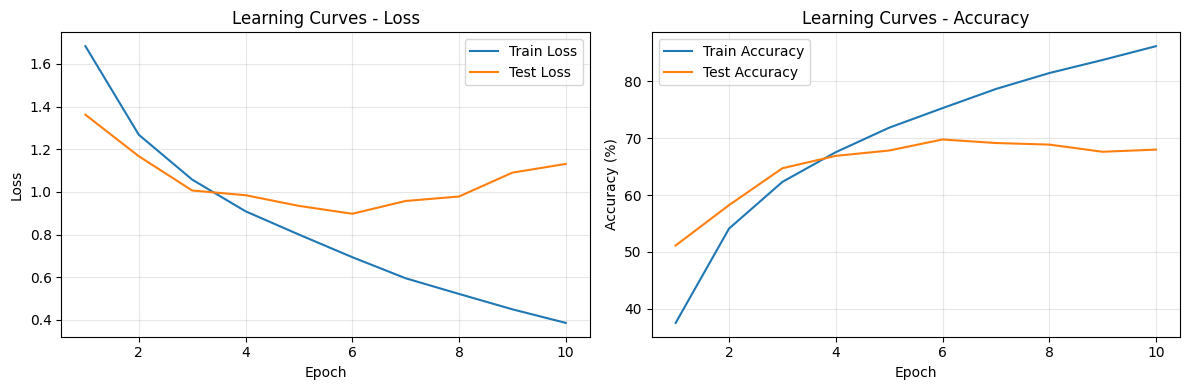

In [36]:
plot_learning_curves(train_losses_1, test_losses_1,train_accuracies_1, test_accuracies_1, epochs)

## Entrenar modelo B

Epoch [1/10]
  Train Loss: 1.7758 | Train Acc: 35.00%
  Test Loss:  1.5376 | Test Acc:  45.40%
--------------------------------------------------
Epoch [2/10]
  Train Loss: 1.4184 | Train Acc: 48.62%
  Test Loss:  1.2984 | Test Acc:  53.80%
--------------------------------------------------
Epoch [3/10]
  Train Loss: 1.2373 | Train Acc: 55.89%
  Test Loss:  1.0828 | Test Acc:  60.85%
--------------------------------------------------
Epoch [4/10]
  Train Loss: 1.1267 | Train Acc: 59.80%
  Test Loss:  1.0533 | Test Acc:  63.42%
--------------------------------------------------
Epoch [5/10]
  Train Loss: 1.0306 | Train Acc: 64.19%
  Test Loss:  0.9124 | Test Acc:  68.08%
--------------------------------------------------
Epoch [6/10]
  Train Loss: 0.9732 | Train Acc: 65.93%
  Test Loss:  0.8852 | Test Acc:  68.42%
--------------------------------------------------
Epoch [7/10]
  Train Loss: 0.9116 | Train Acc: 68.28%
  Test Loss:  0.8227 | Test Acc:  71.28%
-----------------------------

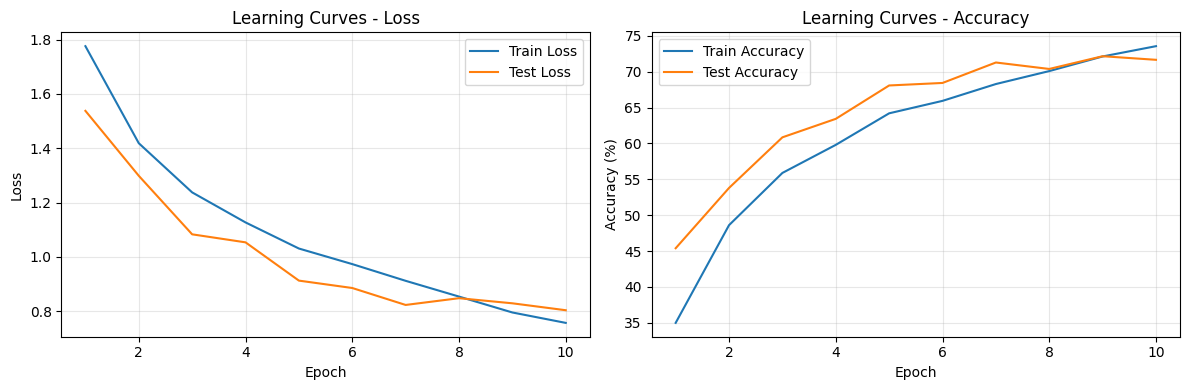

In [37]:
model_2 = CNNModel_B()
model_2 = model_2.to(device)

optimizer_2 = Adam(model_2.parameters(), lr=learning_rate)

# Aquí un poco menor por la complejidad del Modelo B
small_train = Subset(train_data, range(20000))
small_test = Subset(test_data, range(4000))

train_loader = DataLoader(small_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(small_test, batch_size=batch_size, shuffle=True)

train_losses_2, train_accuracies_2, test_losses_2, test_accuracies_2 = train(model_2, train_loader, test_loader, loss_fn, optimizer_2, epochs)

plot_learning_curves(train_losses_2, test_losses_2,train_accuracies_2, test_accuracies_2, epochs)

## Entrenar Modelo C

Epoch [1/10]
  Train Loss: 1.7604 | Train Acc: 33.37%
  Test Loss:  1.4898 | Test Acc:  43.20%
--------------------------------------------------
Epoch [2/10]
  Train Loss: 1.3742 | Train Acc: 50.14%
  Test Loss:  1.2108 | Test Acc:  56.32%
--------------------------------------------------
Epoch [3/10]
  Train Loss: 1.1931 | Train Acc: 57.08%
  Test Loss:  1.0988 | Test Acc:  60.32%
--------------------------------------------------
Epoch [4/10]
  Train Loss: 1.0683 | Train Acc: 62.08%
  Test Loss:  0.9821 | Test Acc:  65.52%
--------------------------------------------------
Epoch [5/10]
  Train Loss: 0.9764 | Train Acc: 65.71%
  Test Loss:  0.9823 | Test Acc:  65.70%
--------------------------------------------------
Epoch [6/10]
  Train Loss: 0.8936 | Train Acc: 68.94%
  Test Loss:  0.9306 | Test Acc:  67.92%
--------------------------------------------------
Epoch [7/10]
  Train Loss: 0.8301 | Train Acc: 70.68%
  Test Loss:  0.9178 | Test Acc:  68.48%
-----------------------------

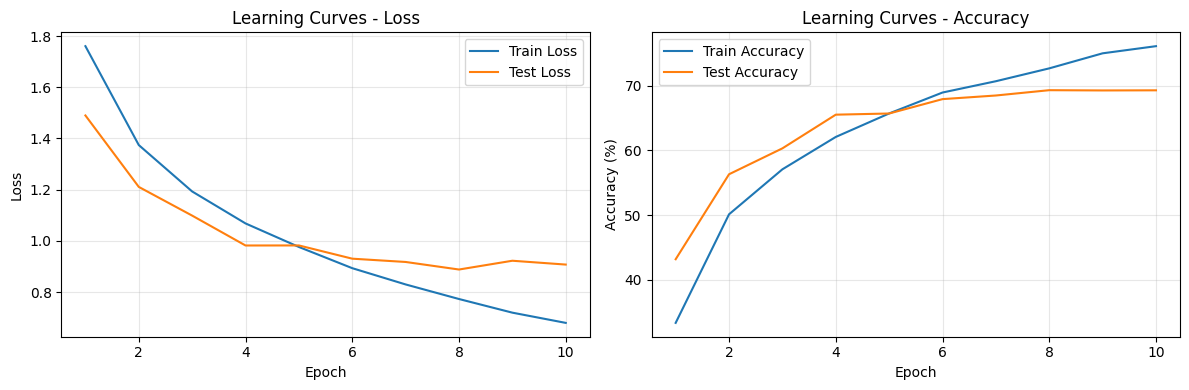

In [38]:
model_3 = CNNModel_C()
model_3 = model_3.to(device)

optimizer_3 = Adam(model_3.parameters(), lr=learning_rate)

small_train = Subset(train_data, range(26000))
small_test = Subset(test_data, range(5000))

train_loader = DataLoader(small_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(small_test, batch_size=batch_size, shuffle=True)

train_losses_3, train_accuracies_3, test_losses_3, test_accuracies_3 = train(model_3, train_loader, test_loader, loss_fn, optimizer_3, epochs)

plot_learning_curves(train_losses_3, test_losses_3,train_accuracies_3, test_accuracies_3, epochs)

# Mejor modelo y reflexiones

El mejor modelo fue el modelo B por sus valores minimizados de Loss y mayores valores de Accuracy en el conjunto de Testing (tomando en consideracion la cantidad reducida de datos por cuestiones de tiempo de ejecucion).

Se me hace interesante notar que el modelo B tuvo mejor desempeno en Test (aunque sea por poco), mientras que el C lo tuvo en Train. Por la manera en la que estuvo construido el modelo B, pense que tendria las mejores chances a tener un gran rendimiento, pero no fue asi. El hecho de que unicamente cambiar el dropout a valores mas grandes en el modelo C haya repercutido en un rendimiento dramaticamente mejor es impresionante para mi.

No siempre es el ajuste de hiperparametros la respuesta a obtener un modelo mejor, sino tambien el experimentar con la arquitectura de este para observar detalles que explican como se puede construir uno mejor.